In [1]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Shared "paper" look used across the benchmarking notebooks (whitegrid + colorblind
# palette + despined axes). Keep these in sync with the other plots/ notebooks so every
# figure in the paper renders consistently.
sns.set_theme(style="whitegrid", context="paper")

# rc overrides applied inside `with sns.plotting_context("paper", rc=PAPER_RC):` per cell.
PAPER_RC = {
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}

# Colour roles, chosen so the two methods we care about pop and the static baselines recede:
#   - DELISEN (adaptive)  -> blue, solid           (the highlighted method)
#   - Prometheus (SOTA)   -> red, dashed + markers (the baseline we compare against)
# Blue-solid vs red-dashed is far easier to separate at a glance than two warm hues.
#   - price_first / bid_first -> plain GREY, dashed/dotted: de-emphasized background
#     references that shouldn't compete with the two coloured methods.
_palette = sns.color_palette("colorblind")
color_adaptive = _palette[0]     # blue (DELISEN — highlighted)
color_prometheus = _palette[3]   # red (Prometheus SOTA family)
color_static = "0.6"             # medium grey for the static filter-order baselines
color_price_first = color_static
color_bid_first = color_static

# Every Prometheus (SOTA) baseline shares the SAME red so the whole family reads as one
# group; individual poll rates are told apart by hatch (bars) and marker + dash (lines),
# never by colour. The static baselines share one grey and are separated by dash pattern.
color_map = {
    "price_first": color_price_first,
    "bid_first": color_bid_first,
    "adaptive": color_adaptive,
    "prometheus": color_prometheus,        # back-compat with a single prometheus.csv
    "prometheus_1000": color_prometheus,
    "prometheus_5000": color_prometheus,
    "prometheus_10000": color_prometheus,
}
fallback_palette = sns.color_palette("colorblind")

# Static filter-order baselines: grey, de-emphasized, separated from each other by dash style.
_STATIC_DASH = {"price_first": (0, (5, 2)), "bid_first": (0, (1, 1))}

# Per-poll-rate patterns so the same-coloured Prometheus variants stay distinguishable.
# Keyed by the poll interval in ms (the suffix of prometheus_<ms>); faster polling first.
_PROM_HATCH = {"1000": "//", "5000": "xx", "10000": ".."}
_PROM_MARKER = {"1000": "s", "5000": "o", "10000": "^"}
_PROM_DASH = {"1000": (0, (4, 2)), "5000": (0, (1, 1)), "10000": (0, (3, 1, 1, 1))}

# Fallback pools for poll rates not in the maps above (an unswept interval), so they still
# get a distinct, deterministic pattern instead of silently collapsing onto one default.
# Indexed by `_prom_fallback_index`; the three pools share an index so a given poll rate's
# line dash, line marker, and bar hatch stay mutually consistent.
_PROM_DASH_POOL = [(0, (6, 2)), (0, (2, 2)), (0, (3, 1, 1, 1, 1, 1)), (0, (5, 1, 1, 1)), (0, (1, 2))]
_PROM_MARKER_POOL = ["D", "v", "P", "X", "*"]
_PROM_HATCH_POOL = ["\\\\", "++", "oo", "**", "OO"]


def _prom_poll_key(name):
    """Poll-interval suffix (e.g. '1000') for a swept Prometheus variant, else None."""
    return name.split("_", 1)[1] if name.startswith("prometheus_") else None


def _prom_fallback_index(key, n):
    """Stable [0, n) index for an unknown poll key: numeric if possible, else a char-sum
    (avoids Python's per-process-randomized str hash so patterns are reproducible)."""
    try:
        return int(key) % n
    except (TypeError, ValueError):
        return sum(ord(c) for c in str(key)) % n


def color_for(name, i=0):
    """Stable colour for a variant name (fixed map, else palette by index)."""
    return color_map.get(name, fallback_palette[i % len(fallback_palette)])


# Line styling per variant:
#   - DELISEN (adaptive)      -> solid, no marker (stands out as the highlighted method)
#   - static price/bid_first  -> grey, dashed/dotted, no marker (de-emphasized references)
#   - Prometheus (SOTA)       -> per-poll-rate dash + marker (matches the engine-vs-Prometheus
#     convention in AddStatisticQueriesOverTime.ipynb; the markers + red keep it clearly
#     distinct from DELISEN's solid blue, even in grayscale prints).
def style_for(name):
    """(linestyle, marker) for a variant."""
    if name in _STATIC_DASH:
        return (_STATIC_DASH[name], None)
    if not name.startswith("prometheus"):
        return ("-", None)
    key = _prom_poll_key(name)
    if key is None:                       # single prometheus.csv (no poll-rate suffix)
        return ("--", "s")
    if key in _PROM_DASH:
        return (_PROM_DASH[key], _PROM_MARKER[key])
    idx = _prom_fallback_index(key, len(_PROM_DASH_POOL))
    return (_PROM_DASH_POOL[idx], _PROM_MARKER_POOL[idx])


def hatch_for(name):
    """Bar hatch for a variant: per-poll-rate hatch for Prometheus, none otherwise."""
    if not name.startswith("prometheus"):
        return ""
    key = _prom_poll_key(name)
    if key is None:                       # single prometheus.csv (no poll-rate suffix)
        return "//"
    if key in _PROM_HATCH:
        return _PROM_HATCH[key]
    return _PROM_HATCH_POOL[_prom_fallback_index(key, len(_PROM_HATCH_POOL))]


def label_for(name):
    """Human-readable legend label: `adaptive` -> `DELISEN`; `prometheus_1000` -> `Prometheus (1s)`;
    other variants are title-cased (`bid_first` -> `Bid First`).

    Prometheus poll intervals are shown in seconds (the CSV suffix is in ms); `:g` drops
    trailing zeros so 1000 ms -> '1s' and 500 ms -> '0.5s'.
    """
    if name == "adaptive":
        return "DELISEN"
    if name == "prometheus":
        return "Prometheus"
    if name.startswith("prometheus_"):
        seconds = int(name.split("_", 1)[1]) / 1000
        return f"Prometheus ({seconds:g}s)"
    return name.replace("_", " ").title()


def is_prometheus(name):
    """True for any Prometheus baseline variant (single or poll-rate-swept)."""
    return name.startswith("prometheus")


def style_time_axis(ax):
    """Apply the shared paper styling to a throughput-over-time axis."""
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Throughput [MTup/s]")
    ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)


output_dir = "."

# CSV files the plotting cells expect to find inside `comparison_dir`.
# These are produced by run_adaptive_optimization_benchmark.sh: one per non-prometheus
# variant, plus one prometheus_<ms>.csv per swept poll interval (POLL_INTERVALS).
EXPECTED_CSVS = [
    "adaptive.csv",
    "bid_first.csv",
    "price_first.csv",
    "prometheus_1000.csv",
    "prometheus_5000.csv",
    "prometheus_10000.csv",
]

# Only plot the steady-state window [WINDOW_START_S, WINDOW_END_S] (seconds),
# dropping the warm-up before WINDOW_START_S and the tail after WINDOW_END_S.
# timestamp_ms is already relative to run start (see write_throughput_csv).
WINDOW_START_S = 5
WINDOW_END_S = 500

# Average throughput into fixed time bins of this width (ms) before plotting.
BIN_MS = 1000

# Draw a marker only every Nth binned point so the Prometheus square markers stay legible
# instead of fusing into a solid band over the (cropped, binned) time series.
MARKEVERY = 12


def crop_to_window(df, start_s=WINDOW_START_S, end_s=WINDOW_END_S):
    """Keep rows in [start_s, end_s] seconds and normalize so time starts at 0."""
    start_ms, end_ms = start_s * 1000, end_s * 1000
    df = df[(df["timestamp_ms"] >= start_ms) & (df["timestamp_ms"] <= end_ms)].copy()
    df["timestamp_ms"] = df["timestamp_ms"] - start_ms
    return df


def average_per_bin(df, bin_ms=BIN_MS):
    """Average throughput within fixed `bin_ms` time bins; index each point at its bin start."""
    df = df.copy()
    df["timestamp_ms"] = (df["timestamp_ms"] // bin_ms) * bin_ms
    return df.groupby("timestamp_ms", as_index=False)["throughput_tup_per_s"].mean()


def load_data_only(path):
    df = pd.read_csv(path)
    if "query_type" in df.columns:
        df = df[df["query_type"] == "data"]
    return average_per_bin(crop_to_window(df))


def variant_sort_key(path):
    """Sort variants for stable legend order: non-adaptive first, prometheus poll rates in
    ascending numeric order (so 5000 ms precedes 10000 ms, not alphabetical), adaptive last."""
    base = os.path.splitext(os.path.basename(path))[0]
    is_adaptive = base == "adaptive"
    poll_ms = int(base.split("_", 1)[1]) if base.startswith("prometheus_") else -1
    return (is_adaptive, base.startswith("prometheus"), poll_ms, base)


def sorted_csv_paths(comparison_dir):
    """All CSVs in `comparison_dir`, ordered by variant_sort_key."""
    import glob

    return sorted(glob.glob(os.path.join(comparison_dir, "*.csv")), key=variant_sort_key)


def warn_missing_csvs(comparison_dir, expected=EXPECTED_CSVS):
    """Print a warning for any missing CSV (don't raise) and return those present.

    Lets the plotting cells render whatever variants exist while still flagging
    which expected file(s) are absent and how to produce them.
    """
    if os.path.isdir(comparison_dir):
        missing = [n for n in expected if not os.path.isfile(os.path.join(comparison_dir, n))]
    else:
        missing = list(expected)
    if missing:
        listing = "\n".join(f"  - {n}" for n in missing)
        print(
            f"WARNING: missing throughput CSV(s) in '{os.path.abspath(comparison_dir)}':\n"
            f"{listing}\n"
            "These variants will be skipped. To produce them, run the benchmark wrapper:\n"
            "  scripts/benchmarking/adaptive-optimization/run_adaptive_optimization_benchmark.sh \\\n"
            f"      --results-dir {comparison_dir}\n"
        )
    return [n for n in expected if n not in missing]

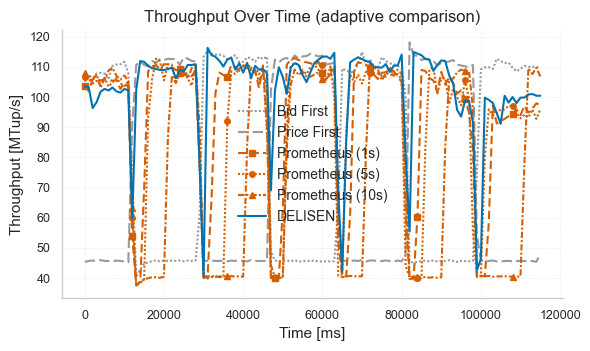

In [2]:
comparison_dir = "."
# Warn about any missing variant (e.g. adaptive.csv) but plot whatever exists.
warn_missing_csvs(comparison_dir)

# Each prometheus_<ms>.csv is its own variant/hue; sorted so poll rates ascend in the legend.
csv_paths = sorted_csv_paths(comparison_dir)

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    for i, path in enumerate(csv_paths):
        name = os.path.splitext(os.path.basename(path))[0]
        df = load_data_only(path)
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            df["throughput_tup_per_s"] / 1e6,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=label_for(name),
        )

    ax.set_title("Throughput Over Time (adaptive comparison)")
    style_time_axis(ax)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/throughput_over_time_adaptive_comparison.pdf", dpi=300, bbox_inches="tight")
    plt.show()

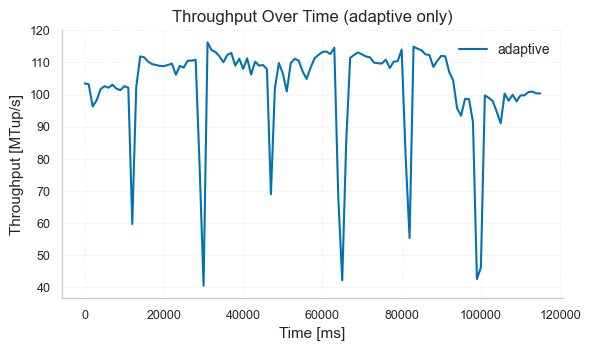

In [3]:
if not warn_missing_csvs(comparison_dir, expected=["adaptive.csv"]):
    print("Skipping adaptive-only plot.")
else:
    adaptive_path = os.path.join(comparison_dir, "adaptive.csv")
    df_adaptive_only = load_data_only(adaptive_path)

    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(6.0, 3.6))
        ax.plot(
            df_adaptive_only["timestamp_ms"],
            df_adaptive_only["throughput_tup_per_s"] / 1e6,
            color=color_adaptive,
            linewidth=1.5,
            label="adaptive",
        )

        ax.set_title("Throughput Over Time (adaptive only)")
        style_time_axis(ax)
        ax.legend(frameon=False)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/throughput_over_time_adaptive_only.pdf", dpi=300, bbox_inches="tight")
        plt.show()

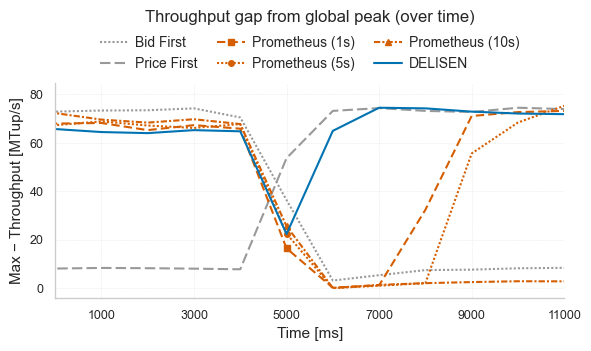

In [4]:
# Pick the single maximum throughput value across all variants, then plot (max - value)
# over time for each variant: the gap from the global peak throughput. The variant that
# achieves the peak touches 0 there; larger values are further below the best observed.
from matplotlib.ticker import FuncFormatter

warn_missing_csvs(comparison_dir)

csv_paths = sorted_csv_paths(comparison_dir)
dfs = {os.path.splitext(os.path.basename(p))[0]: load_data_only(p) for p in csv_paths}

# The single maximum throughput value over every variant and timestamp.
#global_max = max(df["throughput_tup_per_s"].max() for df in dfs.values())
global_min = min(df["throughput_tup_per_s"].min() for df in dfs.values())

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    for i, (name, df) in enumerate(dfs.items()):
        # Gap from the peak; clamp negatives (throughput above global_max) to 0.
        gap = (df["throughput_tup_per_s"] - global_min) / 1e6
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            gap,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=label_for(name),
        )

    # Layout top-to-bottom: title, then legend, then plot. The title is padded up to leave
    # room for the legend, which is anchored just above the axes and spread across columns.
    ax.set_title("Throughput gap from global peak (over time)", pad=44)
    style_time_axis(ax)
    ax.set_ylabel("Max − Throughput [MTup/s]")
    # Start the plotted window at the 7 s mark of the data, but offset the tick labels so the
    # left edge reads 0 (labels = data time − x_offset).
    x_offset = 7000
    ax.set_xlim(left=x_offset, right=18_000)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x - x_offset)}"))
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        frameon=False,
        columnspacing=1.4,
        handletextpad=0.5,
    )

    plt.tight_layout()
    plt.savefig(f"{output_dir}/throughput_over_time_gap_from_max.pdf", dpi=300, bbox_inches="tight")
    plt.show()

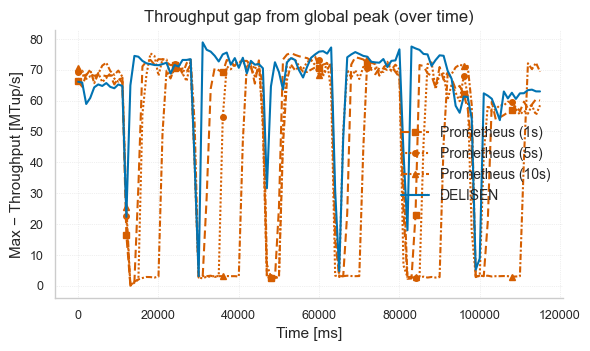

In [5]:
# Same as the gap-from-global-peak plot above, but excluding the bid_first and price_first
# variants (only adaptive + the Prometheus poll-rate sweep are shown).
warn_missing_csvs(comparison_dir)

csv_paths = sorted_csv_paths(comparison_dir)
dfs = {os.path.splitext(os.path.basename(p))[0]: load_data_only(p) for p in csv_paths}

# Drop the static filter-order baselines.
dfs = {name: df for name, df in dfs.items() if name not in ("bid_first", "price_first")}

# The single maximum throughput value over every variant and timestamp.
#global_max = max(df["throughput_tup_per_s"].max() for df in dfs.values())
global_min = min(df["throughput_tup_per_s"].min() for df in dfs.values())

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    for i, (name, df) in enumerate(dfs.items()):
        # Gap from the peak; clamp negatives (throughput above global_max) to 0.
        gap = (df["throughput_tup_per_s"] - global_min) / 1e6
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            gap,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=label_for(name),
        )

    ax.set_title("Throughput gap from global peak (over time)")
    style_time_axis(ax)
    ax.set_ylabel("Max − Throughput [MTup/s]")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/throughput_over_time_gap_from_max_no_static.pdf", dpi=300, bbox_inches="tight")
    plt.show()

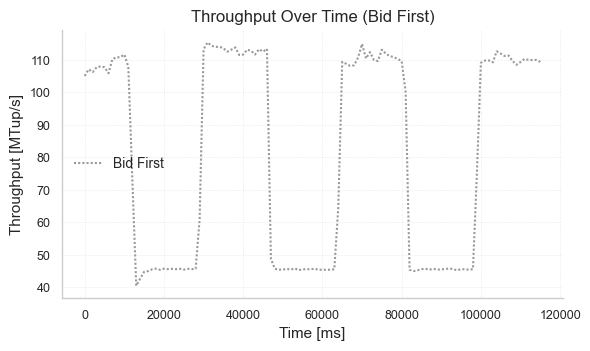

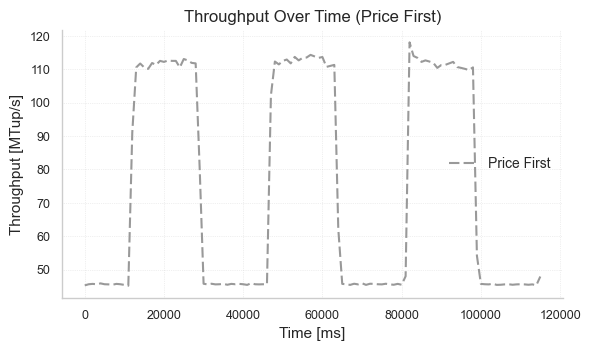

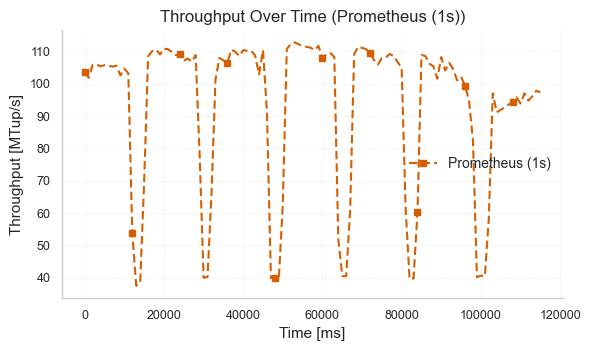

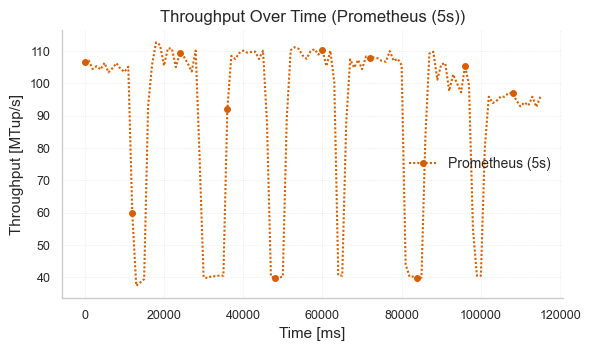

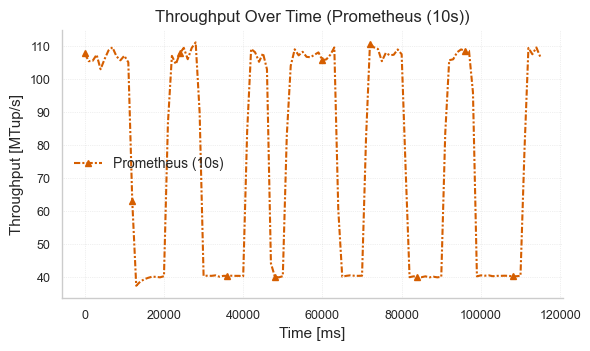

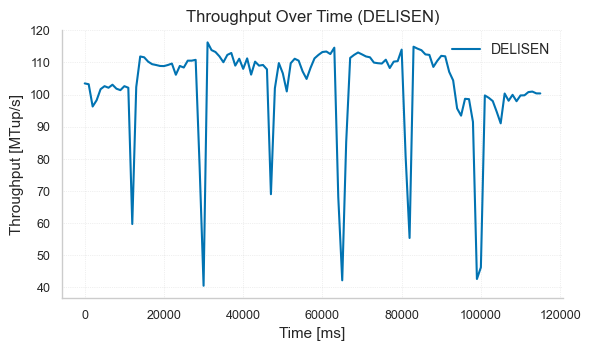

In [6]:
# Same as the comparison plot, but each variant is drawn in its own separate figure.
warn_missing_csvs(comparison_dir)

csv_paths = sorted_csv_paths(comparison_dir)
for i, path in enumerate(csv_paths):
    name = os.path.splitext(os.path.basename(path))[0]
    df = load_data_only(path)

    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(6.0, 3.6))
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            df["throughput_tup_per_s"] / 1e6,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=label_for(name),
        )

        ax.set_title(f"Throughput Over Time ({label_for(name)})")
        style_time_axis(ax)
        ax.legend(frameon=False)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/throughput_over_time_{name}.pdf", dpi=300, bbox_inches="tight")
        plt.show()

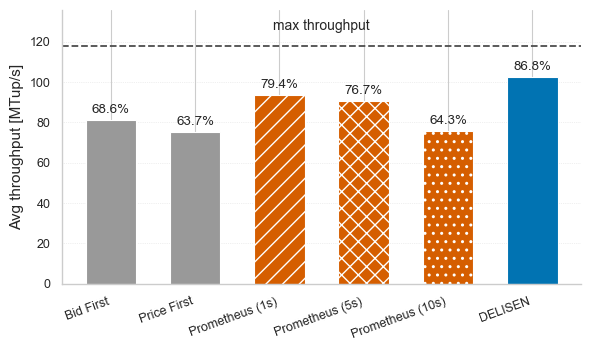

In [7]:
# Bar plot of each variant's average throughput over the whole (cropped, binned) run.
import matplotlib.transforms as mtransforms

warn_missing_csvs(comparison_dir)

csv_paths = sorted_csv_paths(comparison_dir)
names, means, colors, hatches = [], [], [], []
# Peak of the BIN_MS-binned throughput across all variants — the dashed reference below. Taken
# over the binned series so a transient per-sample spike doesn't inflate it.
peak_binned = 0.0
for i, path in enumerate(csv_paths):
    name = os.path.splitext(os.path.basename(path))[0]
    df = load_data_only(path)
    names.append(label_for(name))
    means.append(df["throughput_tup_per_s"].mean() / 1e6)
    peak_binned = max(peak_binned, df["throughput_tup_per_s"].max() / 1e6)
    colors.append(color_for(name, i))
    # Hatch every Prometheus (SOTA) bar so the same-coloured family stays distinguishable
    # in grayscale prints; each swept poll rate gets its own hatch (matching the per-poll-rate
    # dash/marker treatment of their lines in the time-series plots).
    hatches.append(hatch_for(name))

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    bars = ax.bar(names, means, color=colors, width=0.6)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    # Label each bar with its average throughput as a percentage of the max-throughput reference.
    pct_labels = [f"{(m / peak_binned * 100):.1f}%" if peak_binned else "" for m in means]
    ax.bar_label(bars, labels=pct_labels, padding=3)

    # Dashed horizontal reference at the binned maximum throughput across all variants. The bars
    # are run-averages, so this line marks the best *sustained* (binned) throughput any variant
    # reached — the ceiling the averages sit below.
    if names:
        ax.axhline(
            peak_binned,
            linestyle="--",
            color="0.3",
            linewidth=1.3,
            label="max throughput",
        )
        # Headroom above the line so the legend can sit above it without clipping.
        ax.set_ylim(top=peak_binned * 1.15)
        # Legend centered just above the dashed line: blended transform → x in axes fraction
        # (0.5 = centre), y in data coords (the line value). handlelength=0 drops the line sample.
        trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        ax.legend(
            loc="lower center",
            bbox_to_anchor=(0.5, peak_binned),
            bbox_transform=trans,
            frameon=False,
            handlelength=0,
            handletextpad=0,
        )

    ax.set_ylabel("Avg throughput [MTup/s]")
    #ax.set_title("Average Throughput per Variant")
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)
    plt.xticks(rotation=20, ha="right")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/average_throughput_bar.pdf", dpi=300, bbox_inches="tight")
    plt.show()